# Set-up

## Imports

In [1]:
# Custom functions for loading in the PPP, POND, ABCD, and HBN data
from functions.load_data import load_ppp, load_pond, load_hbn, load_abcd 

# Custom functions for setting the tuning directories
from functions.load_data import tuning_dir_ppp, tuning_dir_pond, tuning_dir_hbn, tuning_dir_abcd

# Built-in functions
import pandas as pd
import numpy as np
import os
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score, accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from fairlearn.metrics import demographic_parity_ratio
from scipy.stats import mode
import shap

## Parameters

In [2]:
# Specify the folds
num_folds = 5

# Specify the number of bootstraps
num_bootstraps = 10

# Analysis

## Functions

In [ ]:
# Function to compute the ROC curve across a consistent range of thresholds (np.linspace(0, 1, 101))
def roc_stats(y_true, y_pred):

    # ROC AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    
    # Interpolate to common space (every round threshold)
    tpr = np.interp(np.linspace(0, 1, 101), fpr, tpr)
    tpr[0] = 0.0

    return  tpr

# Function to compute ROC-AUC, PR-AUC, accuracy, and confusion matrix
def compute_metrics(y_true, y_scores, threshold=0.5):

    # Compute metrics
    auc = roc_auc_score(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)  
    y_pred = (y_scores >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn) if (tp+fn) else np.nan
        spec = tn / (tn + fp) if (tn+fp) else np.nan
    else:
        sens, spec = np.nan, np.nan
    
    return auc, pr_auc, acc, cm, sens, spec

# Compute mean and 95% confidence intervals
def calculate_stats(group):
    stats = {}
    for col in group.columns:
        mean = group[col].mean()
        sem = group[col].sem()
        stats[col + '_mean'] = mean
        stats[col + '_ci95_lo'] = mean - 1.96 * sem
        stats[col + '_ci95_hi'] = mean + 1.96 * sem
    return pd.Series(stats)

# Two-layer deep neural network for base learner
def build_nn(input_dim, hidden_units=64, lr=1e-3):

    # Initialize
    model = Sequential()

    # First hidden layer
    model.add(Dense(hidden_units, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.3))

    # Second hidden layer
    model.add(Dense(hidden_units, activation='relu'))
    model.add(Dropout(0.3))
    
    # Output layer (binary)
    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=lr),
        metrics=['accuracy']
    )
    
    return model

# Supress undefined metric warnings
def warn(*args, **kwargs):
    pass
warnings.warn = warn
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# Function for undersampling the negative class
def undersample(df, y_var, rs, id_col):

    # Undersample negative class
    data_pos = df.loc[df[y_var] == 1]
    data_neg = df.loc[df[y_var] == 0].sample(n=np.shape(data_pos)[0], random_state=rs)
    data = pd.concat((data_pos, data_neg), axis=0).sort_values(id_col)
    ind_orig = list(data.index)
    data = data.reset_index(drop=True)

    return ind_orig, data

# Function to test the stacked ensemble on an external dataset
def train_stacked_ensemble(df, subject_col, predictors, y_vars, num_bootstraps, tuning_dir):

    # Initalize the data frame storing the results
    results = pd.DataFrame(columns=['Outcome', 'Bootstrap', 'Fold', 'ROC AUC', 'PR AUC', 'Accuracy', 'CM', 'Sens', 'Spec'])
    
    # Initialize the data frame storing the TPRs
    tprs = pd.DataFrame(columns=['Outcome', 'Bootstrap', 'Fold'] + list(np.linspace(0, 1, 101)))

    # Initialize the feature importances
    exps = []
    
    # Initialize the cross-validator
    skf = StratifiedKFold(n_splits=num_folds, shuffle = True, random_state = 20)
    
    # Iterate over the predicion variables
    for ind, y_var in enumerate(y_vars):
    
        # Iterate across bootstraps
        for bootstrap in range(0, num_bootstraps):
    
            # Undersample negative class
            ind_orig, data = undersample(df, y_var, ind*bootstrap, subject_col)
    
            # Extract X and y
            X_boot = data[predictors].astype(float)
            y_boot = data[y_var].astype(int)
    
            # Prepare out-of-fold (OOF) arrays for base learners (CatBoost & NN)
            oof_cat = np.zeros(len(X_boot), dtype=np.float32)
            oof_nn  = np.zeros(len(X_boot), dtype=np.float32)
    
            # Store fold indices for evaluation
            fold_indices = []        
    
            # Iterate over the folds
            for fold, (train_idx, valid_idx) in enumerate(skf.split(X_boot, y_boot)):
    
                # Extract training and validation data
                X_train, X_valid = X_boot.iloc[train_idx], X_boot.iloc[valid_idx]
                y_train, y_valid = y_boot.iloc[train_idx], y_boot.iloc[valid_idx]
    
                # Only run if the base learner models for the stacked ensemble (SE) haven't already been saved
                model_dir = os.path.join(tuning_dir, 'SE', y_var)
                if not os.path.exists(model_dir):
                    os.makedirs(model_dir)
                model_file = os.path.join(model_dir, 'bootstrap_' + str(bootstrap).zfill(3) + '_fold_' + str(fold).zfill(2) + '_catboost_keras.pkl')
                if not os.path.exists(model_file):
    
                    # (i) Fit CatBoost basse learner
                    cat_model = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, random_seed=40, verbose=False, auto_class_weights='Balanced')
                    cat_model.fit(X_train, y_train)
                    cat_pred = cat_model.predict_proba(X_valid)[:, 1]
        
                    # (ii) Fit NN base learner
                    keras_model = build_nn(input_dim=X_train.shape[1])
                    keras_model.fit(X_train.values, y_train.values, validation_data=(X_valid.values, y_valid.values), epochs=10, batch_size=32, verbose=0)
                    nn_pred = keras_model.predict(X_valid.values).ravel()
    
                    # Save
                    with open(model_file, 'wb') as f:
                        pickle.dump([cat_model, keras_model], f)
    
                else:
    
                    # Load  
                    with open(model_file, 'rb') as f:
                        models = pickle.load(f)
    
                    # Predict using CatBoost model
                    cat_model = models[0]
                    cat_pred = cat_model.predict_proba(X_valid, verbose=False)[:, 1]
    
                    # Predict using Keras model
                    keras_model = models[1]
                    nn_pred = keras_model.predict(X_valid.values, verbose=False).ravel()
    
                # Store both predictions
                oof_cat[valid_idx] = cat_pred
                oof_nn[valid_idx]  = nn_pred
    
                # Store
                fold_indices.append(valid_idx)
    
            # Stack the features
            stacked_features = np.column_stack([oof_cat, oof_nn])
            
            # Only run if the meta learner model for the stacked ensemble (SE) haven't already been saved
            oof_model_file = os.path.join(model_dir, 'bootstrap_' + str(bootstrap).zfill(3) + '_ooflogistic.pkl')
            if not os.path.exists(oof_model_file):
            
                # Out-of-fold prediction
                meta_model = LogisticRegression()
                meta_model.fit(stacked_features, y_boot)
    
                 # Save
                with open(oof_model_file, 'wb') as f:
                    pickle.dump(meta_model, f)
    
            else:
    
                # Load
                with open(oof_model_file, 'rb') as f:
                        meta_model = pickle.load(f)
    
            # Re-iterate over the folds
            for fold_idx, valid_idx in enumerate(fold_indices):
    
                # Extract the data for this fold
                X_meta_valid = stacked_features[valid_idx]
                y_valid_fold = y_boot.iloc[valid_idx]
    
                # Predict using the meta-model
                y_meta_pred_prob = meta_model.predict_proba(X_meta_valid)[:, 1]
    
                # Evaluate performance
                auc, pr_auc, acc, cm, sens, spec = compute_metrics(y_valid_fold, y_meta_pred_prob, threshold=0.5)
                results.loc[len(results)] = [y_var, bootstrap, fold, auc, pr_auc, acc, cm, sens, spec]
    
                # ROC
                tpr = roc_stats(y_valid_fold, y_meta_pred_prob)
                tprs.loc[len(tprs)] = [y_var, bootstrap, fold] + list(tpr)
    
                # Assign the prediction to the default threshold (0.50), to later compute demographic parity ratio
                df.loc[[ind_orig[ind] for ind in valid_idx], [y_var + '_prediction_' + str(bootstrap).zfill(3)]] = (y_meta_pred_prob >= 0.5).astype('int')

        # Choose the best performing model
        temp = results.loc[results['Outcome'] == y_var].sort_values(by='ROC AUC', ascending=False).reset_index(drop=True)
        fold = temp.loc[0, 'Fold']
        bootstrap = temp.loc[0, 'Bootstrap']
        
        # Load that model
        model_dir = os.path.join(tuning_dir, 'SE', y_var)
        model_file = os.path.join(model_dir, 'bootstrap_' + str(bootstrap).zfill(3) + '_fold_' + str(fold).zfill(2) + '_catboost_keras.pkl')
        with open(model_file, 'rb') as f:
            models = pickle.load(f)
        cat_model = models[0]
        keras_model = models[1]
    
        # Load that meta model
        oof_model_file = os.path.join(model_dir, 'bootstrap_' + str(bootstrap).zfill(3) + '_ooflogistic.pkl')
        with open(oof_model_file, 'rb') as f:
                meta_model = pickle.load(f)
     
        # Run SHAP
        explainer_cat = shap.TreeExplainer(cat_model)
        explainer_keras = shap.DeepExplainer(keras_model, data=df[predictors].astype('float32'))
        keras_shap = explainer_keras.shap_values(np.asarray(df[predictors]).astype('float32'))[:, :, 0]
        
        # Create explainer object
        exp = explainer_cat(df[predictors])

        # Compute stacked ensemble SHAP values by weighting the base learnings by the meta learner's coefficients
        exp.values = (exp.values*meta_model.coef_[0][0] + keras_shap*meta_model.coef_[0][1])/2

        # Store
        exps.append(exp)
    
    return df, results, tprs, exps

# Function to test the stacked ensemble
def test_stacked_ensemble(df, subject_col, predictors, y_vars, num_bootstraps, trained_tuning_dir):

    # Initalize the data frame storing the results
    results = pd.DataFrame(columns=['Outcome', 'Bootstrap', 'Fold', 'ROC AUC', 'PR AUC', 'Accuracy', 'CM', 'Sens', 'Spec'])
    
    # Initialize the data frame storing the TPRs
    tprs = pd.DataFrame(columns=['Outcome', 'Bootstrap', 'Fold'] + list(np.linspace(0, 1, 101)))
    
    # Initialize the cross-validator
    skf = StratifiedKFold(n_splits=num_folds, shuffle = True, random_state = 20)
    
    # Iterate over the predicion variables
    for ind, y_var in enumerate(y_vars):
    
        # Iterate across bootstraps
        for bootstrap in range(0, num_bootstraps):
    
            # Undersample negative class
            ind_orig, data = undersample(df, y_var, ind*bootstrap, subject_col)
    
            # Extract X and y
            X_boot = data[predictors].astype(float)
            y_boot = data[y_var].astype(int)
    
            # Prepare out-of-fold (OOF) arrays for base learners (CatBoost & NN)
            oof_cat = np.zeros(len(X_boot), dtype=np.float32)
            oof_nn  = np.zeros(len(X_boot), dtype=np.float32)
    
            # Store fold indices for evaluation
            fold_indices = []        
    
            # Iterate over the folds
            for fold in range(0, num_folds):
    
                # Load in the trained model
                trained_model_dir = os.path.join(trained_tuning_dir, 'SE', y_var)
                trained_model_file = os.path.join(trained_model_dir, 'bootstrap_' + str(bootstrap).zfill(3) + '_fold_' + str(fold).zfill(2) + '_catboost_keras.pkl')
                with open(trained_model_file, 'rb') as f:
                    models_trained = pickle.load(f)
    
                # CatBoost model
                cat_model = models_trained[0]
                cat_pred = cat_model.predict_proba(data[predictors], verbose=False)[:, 1]
    
                # Keras model
                keras_model = models_trained[1]
                nn_pred = keras_model.predict(data[predictors].values, verbose=False).ravel()

                # Stack the features
                stacked_features = np.column_stack([cat_pred, nn_pred])
            
                # Load the trained meta model
                trained_oof_model_file = os.path.join(trained_model_dir, 'bootstrap_' + str(bootstrap).zfill(3) + '_ooflogistic.pkl')
                with open(trained_oof_model_file, 'rb') as f:
                    meta_model_trained = pickle.load(f)

                # Predict using the meta-model            
                y_meta_pred_prob = meta_model_trained.predict_proba(stacked_features)[:, 1]
                
                # Evaluate performance
                auc, pr_auc, acc, cm, sens, spec = compute_metrics(data[y_var], y_meta_pred_prob, threshold=0.5)
                results.loc[len(results)] = [y_var, bootstrap, fold, auc, pr_auc, acc, cm, sens, spec]
    
                # ROC
                tpr = roc_stats(data[y_var], y_meta_pred_prob)
                tprs.loc[len(tprs)] = [y_var, bootstrap, fold] + list(tpr)
    
                # Assign the prediction to the default threshold (0.50), to compute DPR
                df.loc[ind_orig, [y_var + '_trained_prediction_' + str(bootstrap).zfill(3) + '_' + str(fold).zfill(3)]] = (y_meta_pred_prob >= 0.5).astype('int')
    
    return df, results, tprs

def plot_roc_auc(save_dir, tprs):

    # Make sure save directory exists
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # Set font
    plt.rcParams["font.family"] = "Scala Sans Pro"
    plt.rcParams["font.size"] = 12
    
    # Set the palette 
    palette = ['#8dbd61', '#6f459e', '#f66f8d', '#ffb643']
    
    # ROC AUC
    plt.figure(figsize=(3, 3))
    tprs_plot = pd.melt(tprs, id_vars=['Outcome', 'Fold'], value_vars=list(np.linspace(0, 1, 101)), var_name='FPR', value_name='TPR')
    axs = sns.lineplot(tprs_plot, x='FPR', y='TPR', hue='Outcome', errorbar=None, palette=palette, linewidth=1)
    sns.lineplot(x=[0, 1], y=[0, 1], hue=[1, 1], ax=axs, palette=['k'], linewidth=0.5, linestyle='--')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.legend(fontsize=3, loc='lower right')
    axs.set_aspect('equal', adjustable='box')
    axs.set(xlim=(0, 1), ylim=(0, 1), yticks=[0, 0.5, 1.0])
    if not os.path.exists(os.path.join(save_dir, 'roc_curve.png')):
        plt.savefig(os.path.join(save_dir, 'roc_curve.png'), bbox_inches='tight', dpi=500)

# Extract the data required to compute DPR across the research cohorts
def extract_data_dpr(df, y_vars, dpr_vars):

    # Initialize the output
    dpr_data = pd.DataFrame(columns=['Outcome'] + dpr_vars + ['variable', 'prediction'])
    
    # Compute the demographic parity ratio
    for ind, y_var in enumerate(y_vars):

        # See if this was training or external testing
        cols = [col for col in df if col.startswith(y_var + '_trained_prediction_' + str(0).zfill(3))]
        if cols == []:

            # Get the column names containing the prediction
            cols = [col for col in df if col.startswith(y_var + '_prediction_0')]

        else:

            # Compute the mode prediction across all the folds within a bootstrap
            for bootstrap in range(0, num_bootstraps):
            
                # Get the column names containing the prediction
                cols = [col for col in df if col.startswith(y_var + '_trained_prediction_' + str(bootstrap).zfill(3))]
        
                # Assign new column
                df.loc[:, [y_var + '_trained_prediction_mode_' + str(bootstrap).zfill(3)]] = mode(df[cols], axis=1, nan_policy='omit')[0]
        
            # Get the column names containing the mode prediction
            cols = [col for col in df if col.startswith(y_var + '_trained_prediction_mode')]
        
        # Extract only the columns we need
        temp = df[[y_var] + dpr_vars + cols]
    
        # Wide to long
        temp = pd.melt(temp, id_vars=[y_var] + dpr_vars, var_name='variable', value_name='prediction')
    
        # Add column
        temp.loc[:, ['Outcome']] = y_var
    
        # Remove NaNs
        temp = temp.loc[~pd.isna(temp['prediction'])]
    
        # Add to dataframe
        dpr_data = pd.concat((dpr_data, temp))
        
    return dpr_data


# Compute demographic parity ratio for sensitive groups across the folds
def compute_dpr(df, y_vars, dpr_vars):

    # Initialize the output
    dprs = pd.DataFrame(columns=['Outcome', 'Variable', 'DPR'])
    proportions = pd.DataFrame(columns=['Outcome', 'Variable', 'Group', 'Proportion_Positive'])
    
    # Compute the demographic parity ratio
    for ind, y_var in enumerate(y_vars):
    
        # Get the column names containing the prediction
        cols = [col for col in df if col.startswith(y_var + '_prediction_0')]
        if cols == []:

            # Research already done wide to long
            temp = df.loc[df['Outcome'] == y_var]
            
        else:
            
            # Extract only the columns we need
            temp = df[[y_var] + dpr_vars + cols]
    
            # Wide to long
            temp = pd.melt(temp, id_vars=[y_var] + dpr_vars, var_name='variable', value_name='prediction')
        
        # Remove NaNs
        temp_main = temp.loc[~pd.isna(temp['prediction'])]
    
        # Iterate over the DPR variables
        for dpr_var in dpr_vars:

            # Compute demographic parity
            temp = temp_main.loc[(~pd.isna(temp_main[dpr_var])) & (temp_main[dpr_var] != 'unknown')]
            dpr = demographic_parity_ratio(temp[y_var], temp['prediction'], sensitive_features=temp[dpr_var])            
            dprs.loc[len(dprs)] = [y_var, dpr_var, dpr]
        
            # Compute porportions of positive class for each group
            for group in temp[dpr_var].unique():
                proportions.loc[len(proportions)] = [y_var, dpr_var, group, len(temp.loc[(temp[dpr_var] == group) & (temp['prediction'] == 1)])/len(temp.loc[temp[dpr_var] == group])]

    return dprs, proportions

def plot_shaps(exps, y_vars):

    # Set font
    plt.rcParams["font.family"] = "Scala Sans Pro"
    plt.rcParams["font.size"] = 12
    
    # Specify the save dir
    save_dir = os.path.join(pond_tuning_dir, 'SE')
    
    # Set the palette 
    palette = ['#8dbd61', '#6f459e', '#f66f8d', '#ffb643']
    
    for ind, y_var in enumerate(y_vars):

        # Beeswarm plot - labels
        plt.figure()
        shap.plots.beeswarm(shap_values=exps[ind], show=False, s=16, max_display=10, group_remaining_features=False, color='coolwarm')
        a = plt.gcf().get_children()
        a[1].set_xlabel('', visible=False)
        a[1].set_xlim([-np.max(np.abs(a[1].get_xlim())), np.max(np.abs(a[1].get_xlim()))])
        if not os.path.exists(os.path.join(save_dir, y_var + '_shap_labels.png')):
            plt.savefig(os.path.join(save_dir, y_var + '_shap_labels.png'), bbox_inches='tight', dpi=500)

## Research Cohorts

### Training & Internal Testing

In [4]:
# Load the data 
pond_df, pond_predictors, pond_y_vars = load_pond()

# Output directory for tuning
pond_tuning_dir = tuning_dir_pond()

# Run the stacked ensemble 
pond_df, pond_results, pond_tprs, _ = train_stacked_ensemble(pond_df, 'subject', pond_predictors, pond_y_vars, num_bootstraps, pond_tuning_dir)

# Group the data by 'Outcome' and apply the function to calculate mean ROC AUC
pond_stats = pond_results.groupby('Outcome')[['ROC AUC']].apply(calculate_stats)
print(pond_stats)  

                        ROC AUC_mean  ROC AUC_ci95_lo  ROC AUC_ci95_hi
Outcome                                                               
antidepressant_outcome      0.825499         0.802680         0.848318
antipsychotic_outcome       0.789255         0.756331         0.822178
stimulant_outcome           0.722377         0.707347         0.737407


### External Testing

#### HBN

In [5]:
# Load the data
hbn_df = load_hbn()

# Output directory for saving figures
hbn_tuning_dir = tuning_dir_hbn()

# Test the POND stacked ensemble  on HBN
hbn_df, hbn_results, hbn_tprs = test_stacked_ensemble(hbn_df, 'EID', pond_predictors, pond_y_vars, num_bootstraps, pond_tuning_dir)

# Group the data by 'Outcome' and apply the function to calculate mean ROC AUC
hbn_stats = hbn_results.groupby('Outcome')[['ROC AUC']].apply(calculate_stats)
print(hbn_stats)  

                        ROC AUC_mean  ROC AUC_ci95_lo  ROC AUC_ci95_hi
Outcome                                                               
antidepressant_outcome      0.744599         0.736095         0.753103
antipsychotic_outcome       0.771036         0.757907         0.784164
stimulant_outcome           0.706501         0.700836         0.712166


#### ABCD

In [6]:
# Load the data
abcd_df = load_abcd()

# Output directory for saving figures
abcd_tuning_dir = tuning_dir_abcd()

# Test the POND stacked ensemble on ABCD
abcd_df, abcd_results, abcd_tprs = test_stacked_ensemble(abcd_df, 'src_subject_id', pond_predictors, pond_y_vars, num_bootstraps, pond_tuning_dir)

# Group the data by 'Outcome' and apply the function to calculate mean ROC AUC
abcd_stats = abcd_results.groupby('Outcome')[['ROC AUC']].apply(calculate_stats)
print(hbn_stats)  

                        ROC AUC_mean  ROC AUC_ci95_lo  ROC AUC_ci95_hi
Outcome                                                               
antidepressant_outcome      0.744599         0.736095         0.753103
antipsychotic_outcome       0.771036         0.757907         0.784164
stimulant_outcome           0.706501         0.700836         0.712166


### Demographic Parity

In [7]:
# Extract the data across folds/bootstraps to compute DPR
pond_dpr_data = extract_data_dpr(pond_df, pond_y_vars, ['sex', 'intellectual_disability', 'White_Minority', 'income'])
hbn_dpr_data = extract_data_dpr(hbn_df, pond_y_vars, ['sex', 'intellectual_disability', 'White_Minority', 'income'])
abcd_dpr_data = extract_data_dpr(abcd_df, pond_y_vars, ['sex', 'intellectual_disability', 'White_Minority', 'income'])

# Join
dpr_data = pd.concat((pond_dpr_data, hbn_dpr_data, abcd_dpr_data))

# Compute demographic parity ratio
research_dprs, research_proportions = compute_dpr(dpr_data, pond_y_vars, ['sex', 'intellectual_disability', 'White_Minority', 'income'])
print(research_dprs)

                   Outcome                 Variable       DPR
0        stimulant_outcome                      sex  0.865972
1        stimulant_outcome  intellectual_disability  0.792956
2        stimulant_outcome           White_Minority  0.878753
3        stimulant_outcome                   income  0.928569
4   antidepressant_outcome                      sex  0.744850
5   antidepressant_outcome  intellectual_disability  0.674886
6   antidepressant_outcome           White_Minority  0.699332
7   antidepressant_outcome                   income  0.780025
8    antipsychotic_outcome                      sex  0.758460
9    antipsychotic_outcome  intellectual_disability  0.524951
10   antipsychotic_outcome           White_Minority  0.949372
11   antipsychotic_outcome                   income  0.576730


## EMR cohort

### Training & Internal Testing

In [8]:
# Load the data 
ppp_df, ppp_predictors, ppp_y_vars = load_ppp()

# Output directory for tuning
ppp_tuning_dir = tuning_dir_ppp()

# Run the stacked ensemble 
ppp_df, ppp_results, ppp_tprs, ppp_exps = train_stacked_ensemble(ppp_df, 'study_id2', ppp_predictors, ppp_y_vars, num_bootstraps, ppp_tuning_dir)

# Group the data by 'Outcome' and apply the function to calculate mean ROC AUC
ppp_stats = ppp_results.groupby('Outcome')[['ROC AUC']].apply(calculate_stats)
print(ppp_stats)  

                        ROC AUC_mean  ROC AUC_ci95_lo  ROC AUC_ci95_hi
Outcome                                                               
antidepressant_outcome      0.819982         0.801377         0.838586
antipsychotic_outcome       0.898441         0.882933         0.913949
stimulant_outcome           0.822875         0.816551         0.829199


### Demographic Parity

In [9]:
# Compute the demographic parity ratio
ppp_dprs, ppp_proportions = compute_dpr(ppp_df, ppp_y_vars, ['sex', 'intellectual_disability'])
print(ppp_dprs)

                  Outcome                 Variable       DPR
0       stimulant_outcome                      sex  0.934036
1       stimulant_outcome  intellectual_disability  0.435675
2  antidepressant_outcome                      sex  0.767049
3  antidepressant_outcome  intellectual_disability  0.712848
4   antipsychotic_outcome                      sex  0.906410
5   antipsychotic_outcome  intellectual_disability  0.594335


# Figures

## Figure 2

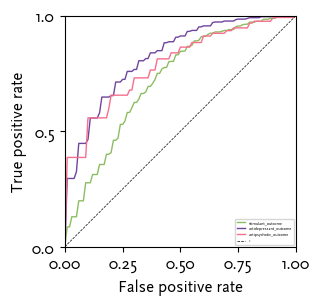

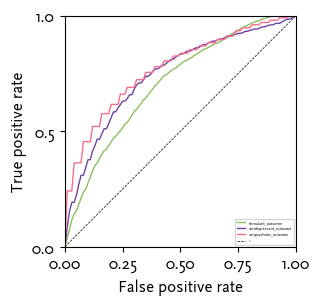

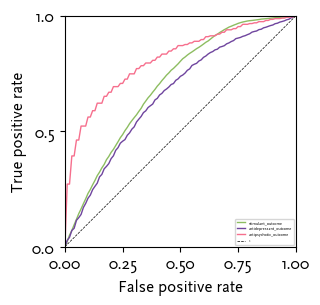

In [10]:
# POND
plot_roc_auc(os.path.join(pond_tuning_dir, 'SE'), pond_tprs)

# HBN
plot_roc_auc(os.path.join(hbn_tuning_dir, 'SE'), hbn_tprs)

# ABCD
plot_roc_auc(os.path.join(abcd_tuning_dir, 'SE'), abcd_tprs)

## Figure 3A

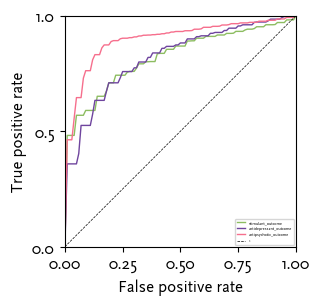

In [11]:
# PPP
plot_roc_auc(os.path.join(ppp_tuning_dir, 'SE'), ppp_tprs)

## Figure 3B

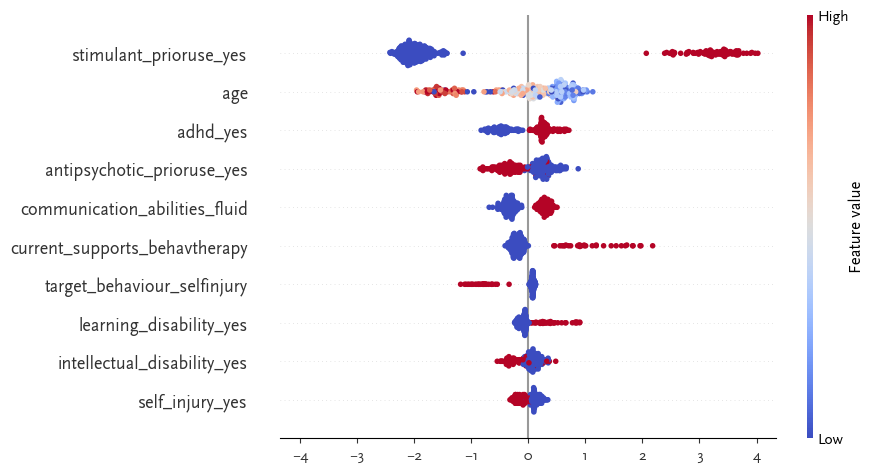

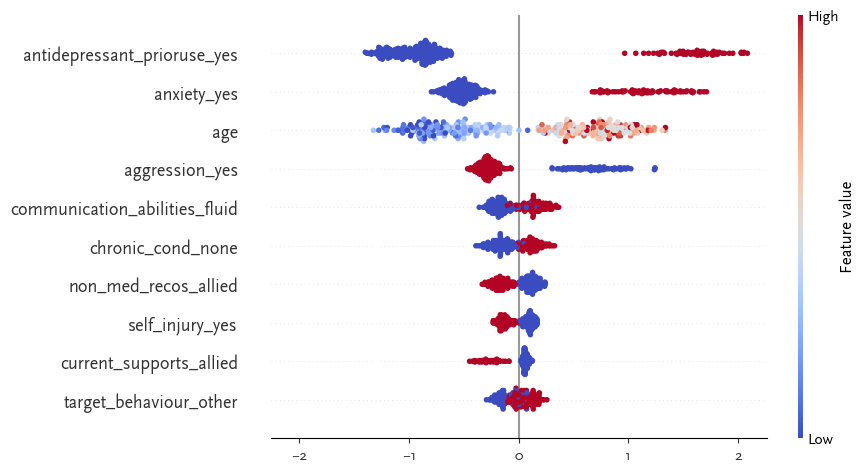

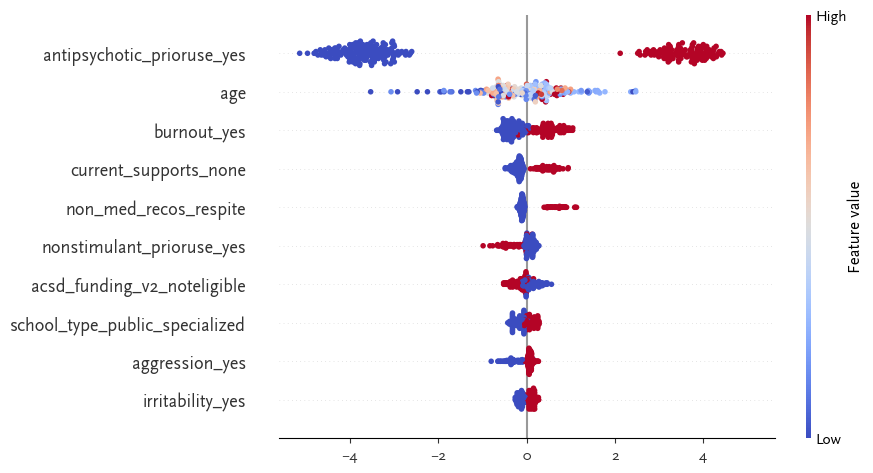

In [12]:
# SHAP values for the EMR cohort
plot_shaps(ppp_exps, ppp_y_vars)